Intiating Libraries

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00


Intergrating Annotated Images to training flow

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="****************")
project = rf.workspace("***********-n4fyg").project("palm-tree-ibnjk")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to palm-tree-1 in yolov8:: 100%|██████████| 167/167 [00:00<00:00, 6656.55it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Mounting google drive to get train test and validation data set

In [3]:
import os
from ultralytics import YOLO

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

folder_path = "/content/palm-tree-1"  # adjust if needed
files = os.listdir(folder_path)

for file in files:
    print(file)

README.roboflow.txt
README.dataset.txt
data.yaml
test
train


In [8]:
for root, dirs, files in os.walk(folder_path):
    for file in files:
        print(os.path.join(root, file))

/content/palm-tree-1/README.roboflow.txt
/content/palm-tree-1/README.dataset.txt
/content/palm-tree-1/data.yaml
/content/palm-tree-1/test/images/TrainRipe-6-_JPG.rf.b4f33253ee9d5c4e56671fbeb973bb7a.jpg
/content/palm-tree-1/test/images/TrainRipe-21-_JPG.rf.3eb4cfdfec29bcdba60880898c26e990.jpg
/content/palm-tree-1/test/images/TrainOverripe-2-_JPG.rf.903f7cf601e2d662f0fbc51d7fc16c35.jpg
/content/palm-tree-1/test/images/TrainUnripe-127-_jpg.rf.3f0a62b276a86865f19a60fc5e5157eb.jpg
/content/palm-tree-1/test/images/TrainUnripe-48-_jpg.rf.b1b5d10977434b763c955e1493fb3c8c.jpg
/content/palm-tree-1/test/images/TrainRipe-39-_jpg.rf.a8fdb3d8136943eeeb85e79a2e817a23.jpg
/content/palm-tree-1/test/images/TrainUnripe-12-_JPG.rf.a9b1a73081c30f79e0276f30106a9ede.jpg
/content/palm-tree-1/test/images/TrainRipe-9-_JPG.rf.b314b06757dd0a03c4f365111ac83791.jpg
/content/palm-tree-1/test/images/TrainUnripe-47-_jpg.rf.3d8d91d0bde824c45a5f91385b5d32a7.jpg
/content/palm-tree-1/test/labels/TrainUnripe-47-_jpg.rf.3d8

Preview data set content

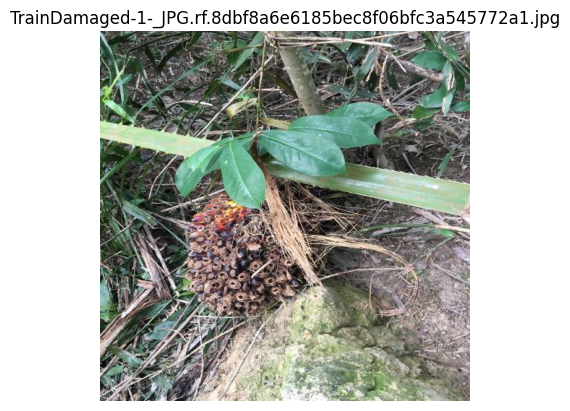

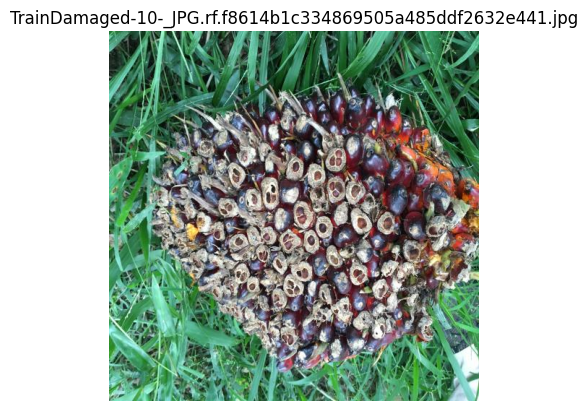

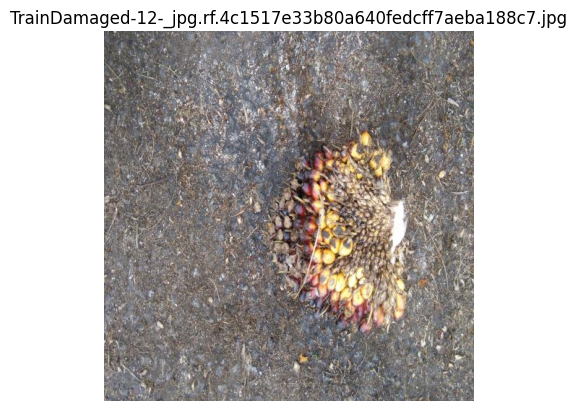

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
train_path = "/content/palm-tree-1/train/images"

# Get list of files
files = sorted(os.listdir(train_path))
image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
top3 = image_files[:3]

for img_name in top3:
    img_path = os.path.join(train_path, img_name)
    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")
    plt.show()

In [13]:
import ultralytics
print(ultralytics.__version__)

8.4.19


In [6]:
!yolo task=detect mode=train model='/content/yolo11n.pt' data='/content/palm-tree-1/data.yaml' epochs=50 plots=True

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/palm-tree-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

Intial resutls graphs for fine tunning

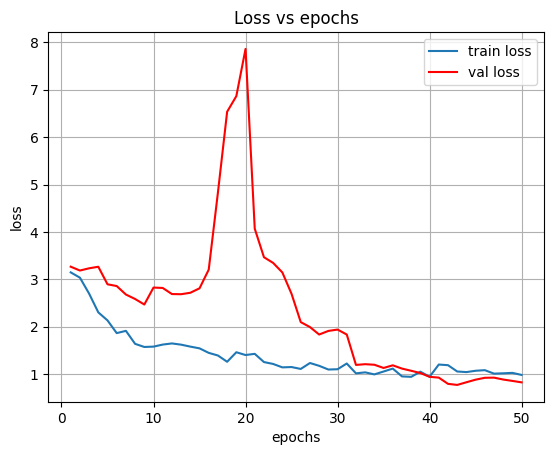

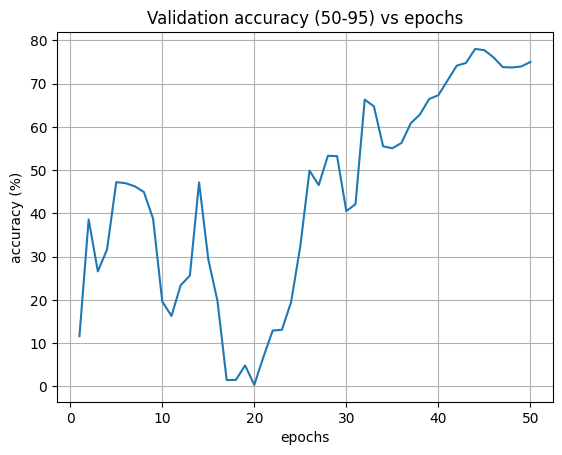

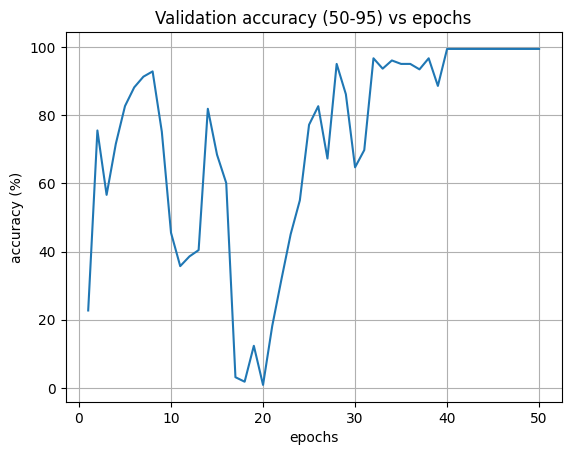

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = '/content/runs/detect/train2/results.csv'

results = pd.read_csv(results_path)

plt.figure()
plt.plot(results['epoch'], results['train/cls_loss'], label='train loss')
plt.plot(results['epoch'], results['val/cls_loss'], label='val loss', c='red')
plt.grid()
plt.title('Loss vs epochs')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend()


plt.figure()
plt.plot(results['epoch'], results['metrics/mAP50-95(B)'] * 100)
plt.grid()
plt.title('Validation accuracy (50-95) vs epochs')
plt.ylabel('accuracy (%)')
plt.xlabel('epochs')

plt.figure()
plt.plot(results['epoch'], results['metrics/mAP50(B)'] * 100)
plt.grid()
plt.title('Validation accuracy (50-95) vs epochs')
plt.ylabel('accuracy (%)')
plt.xlabel('epochs')

plt.show()

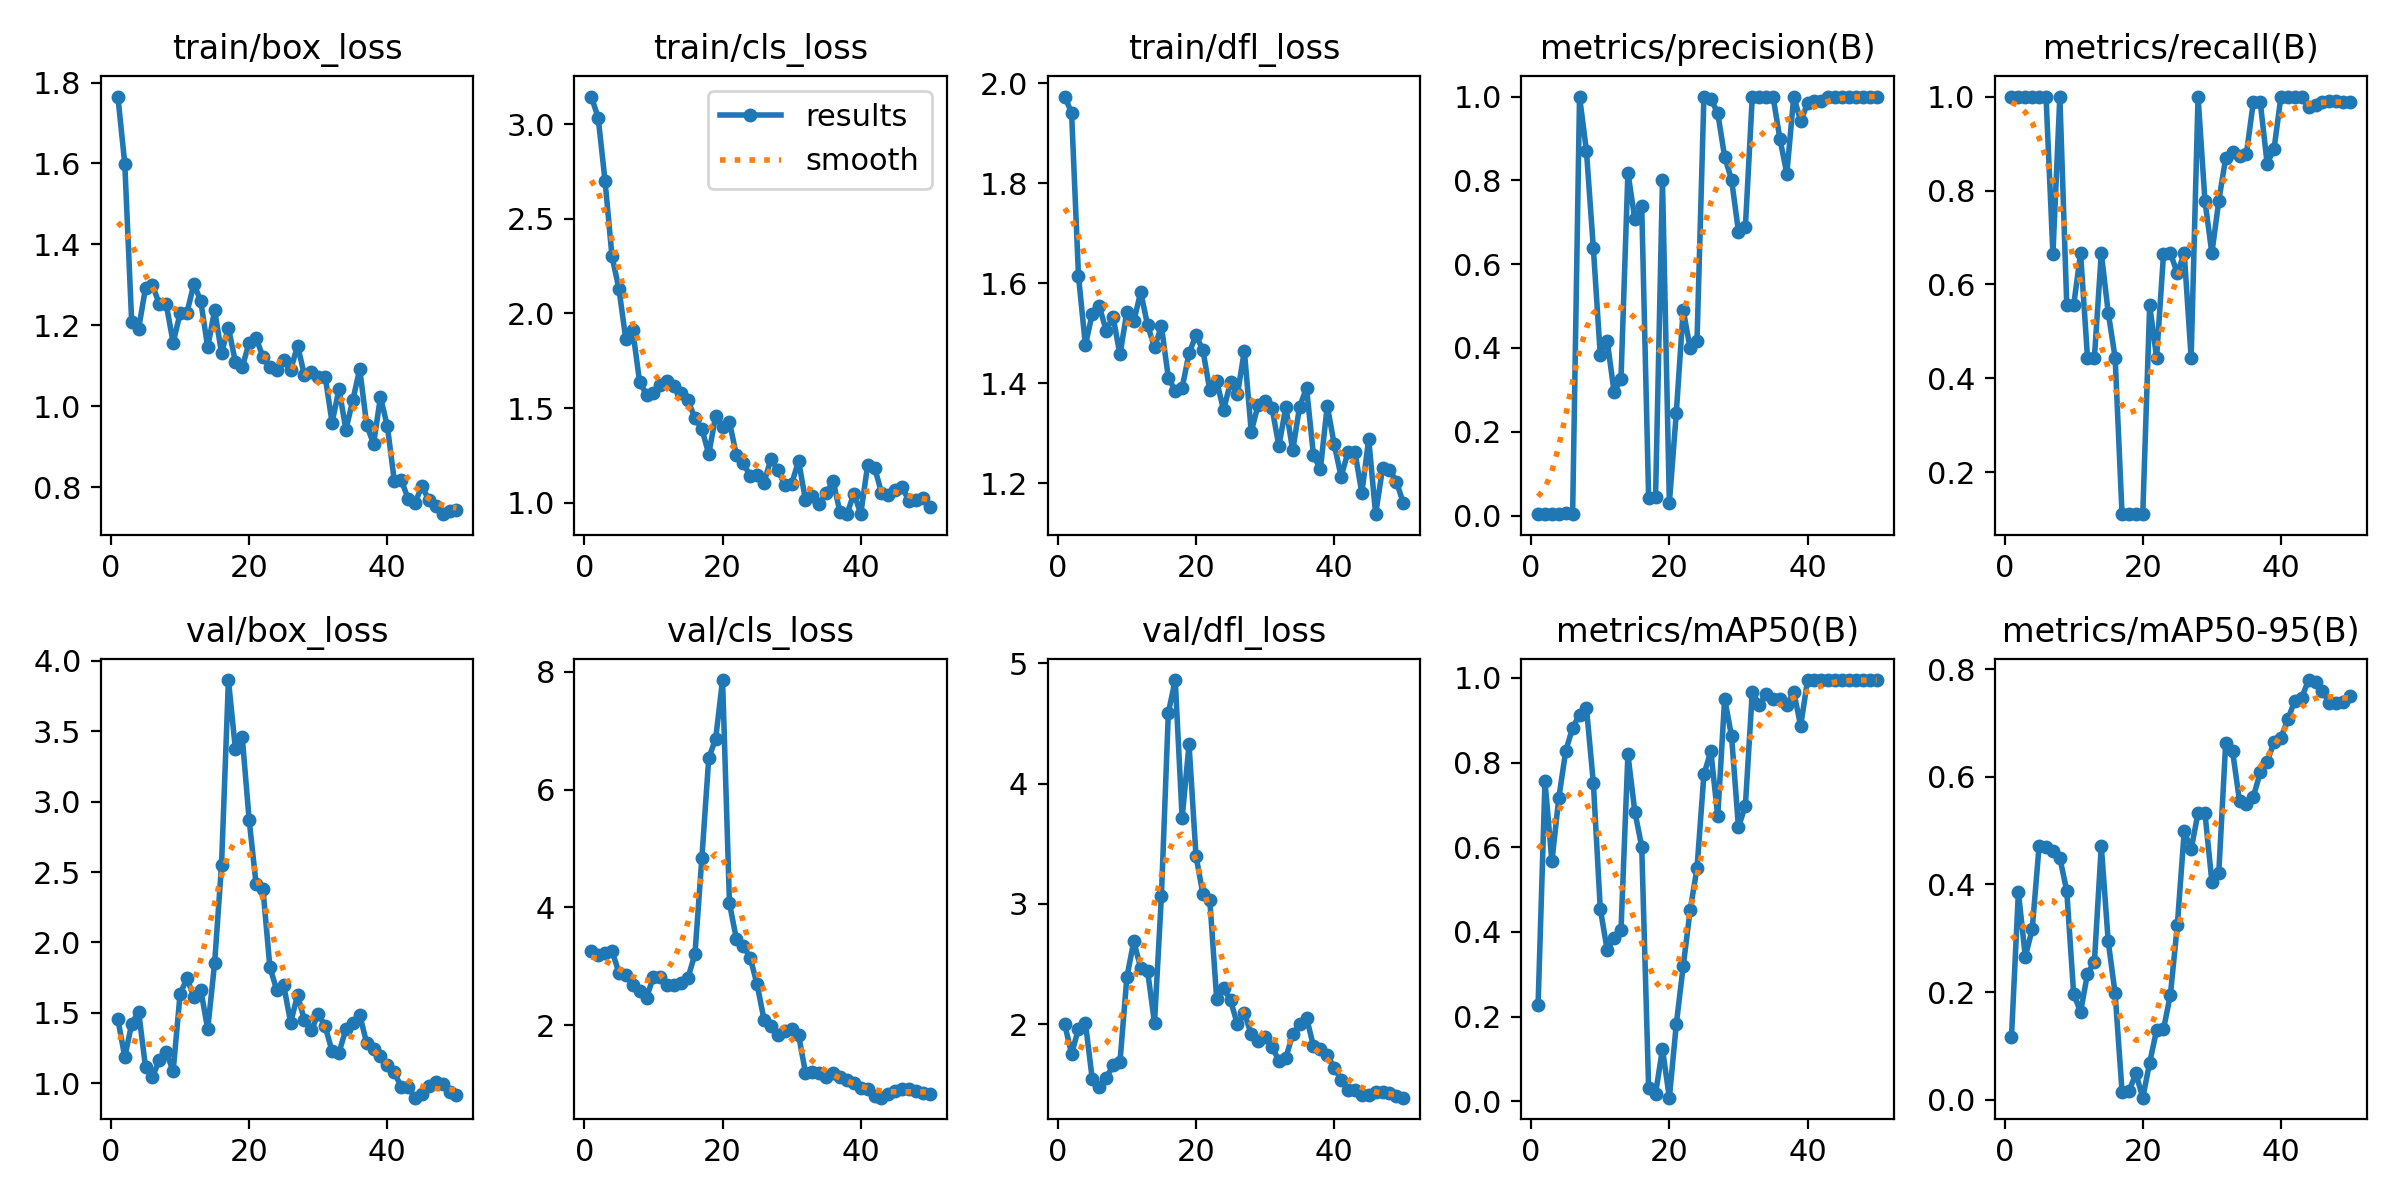

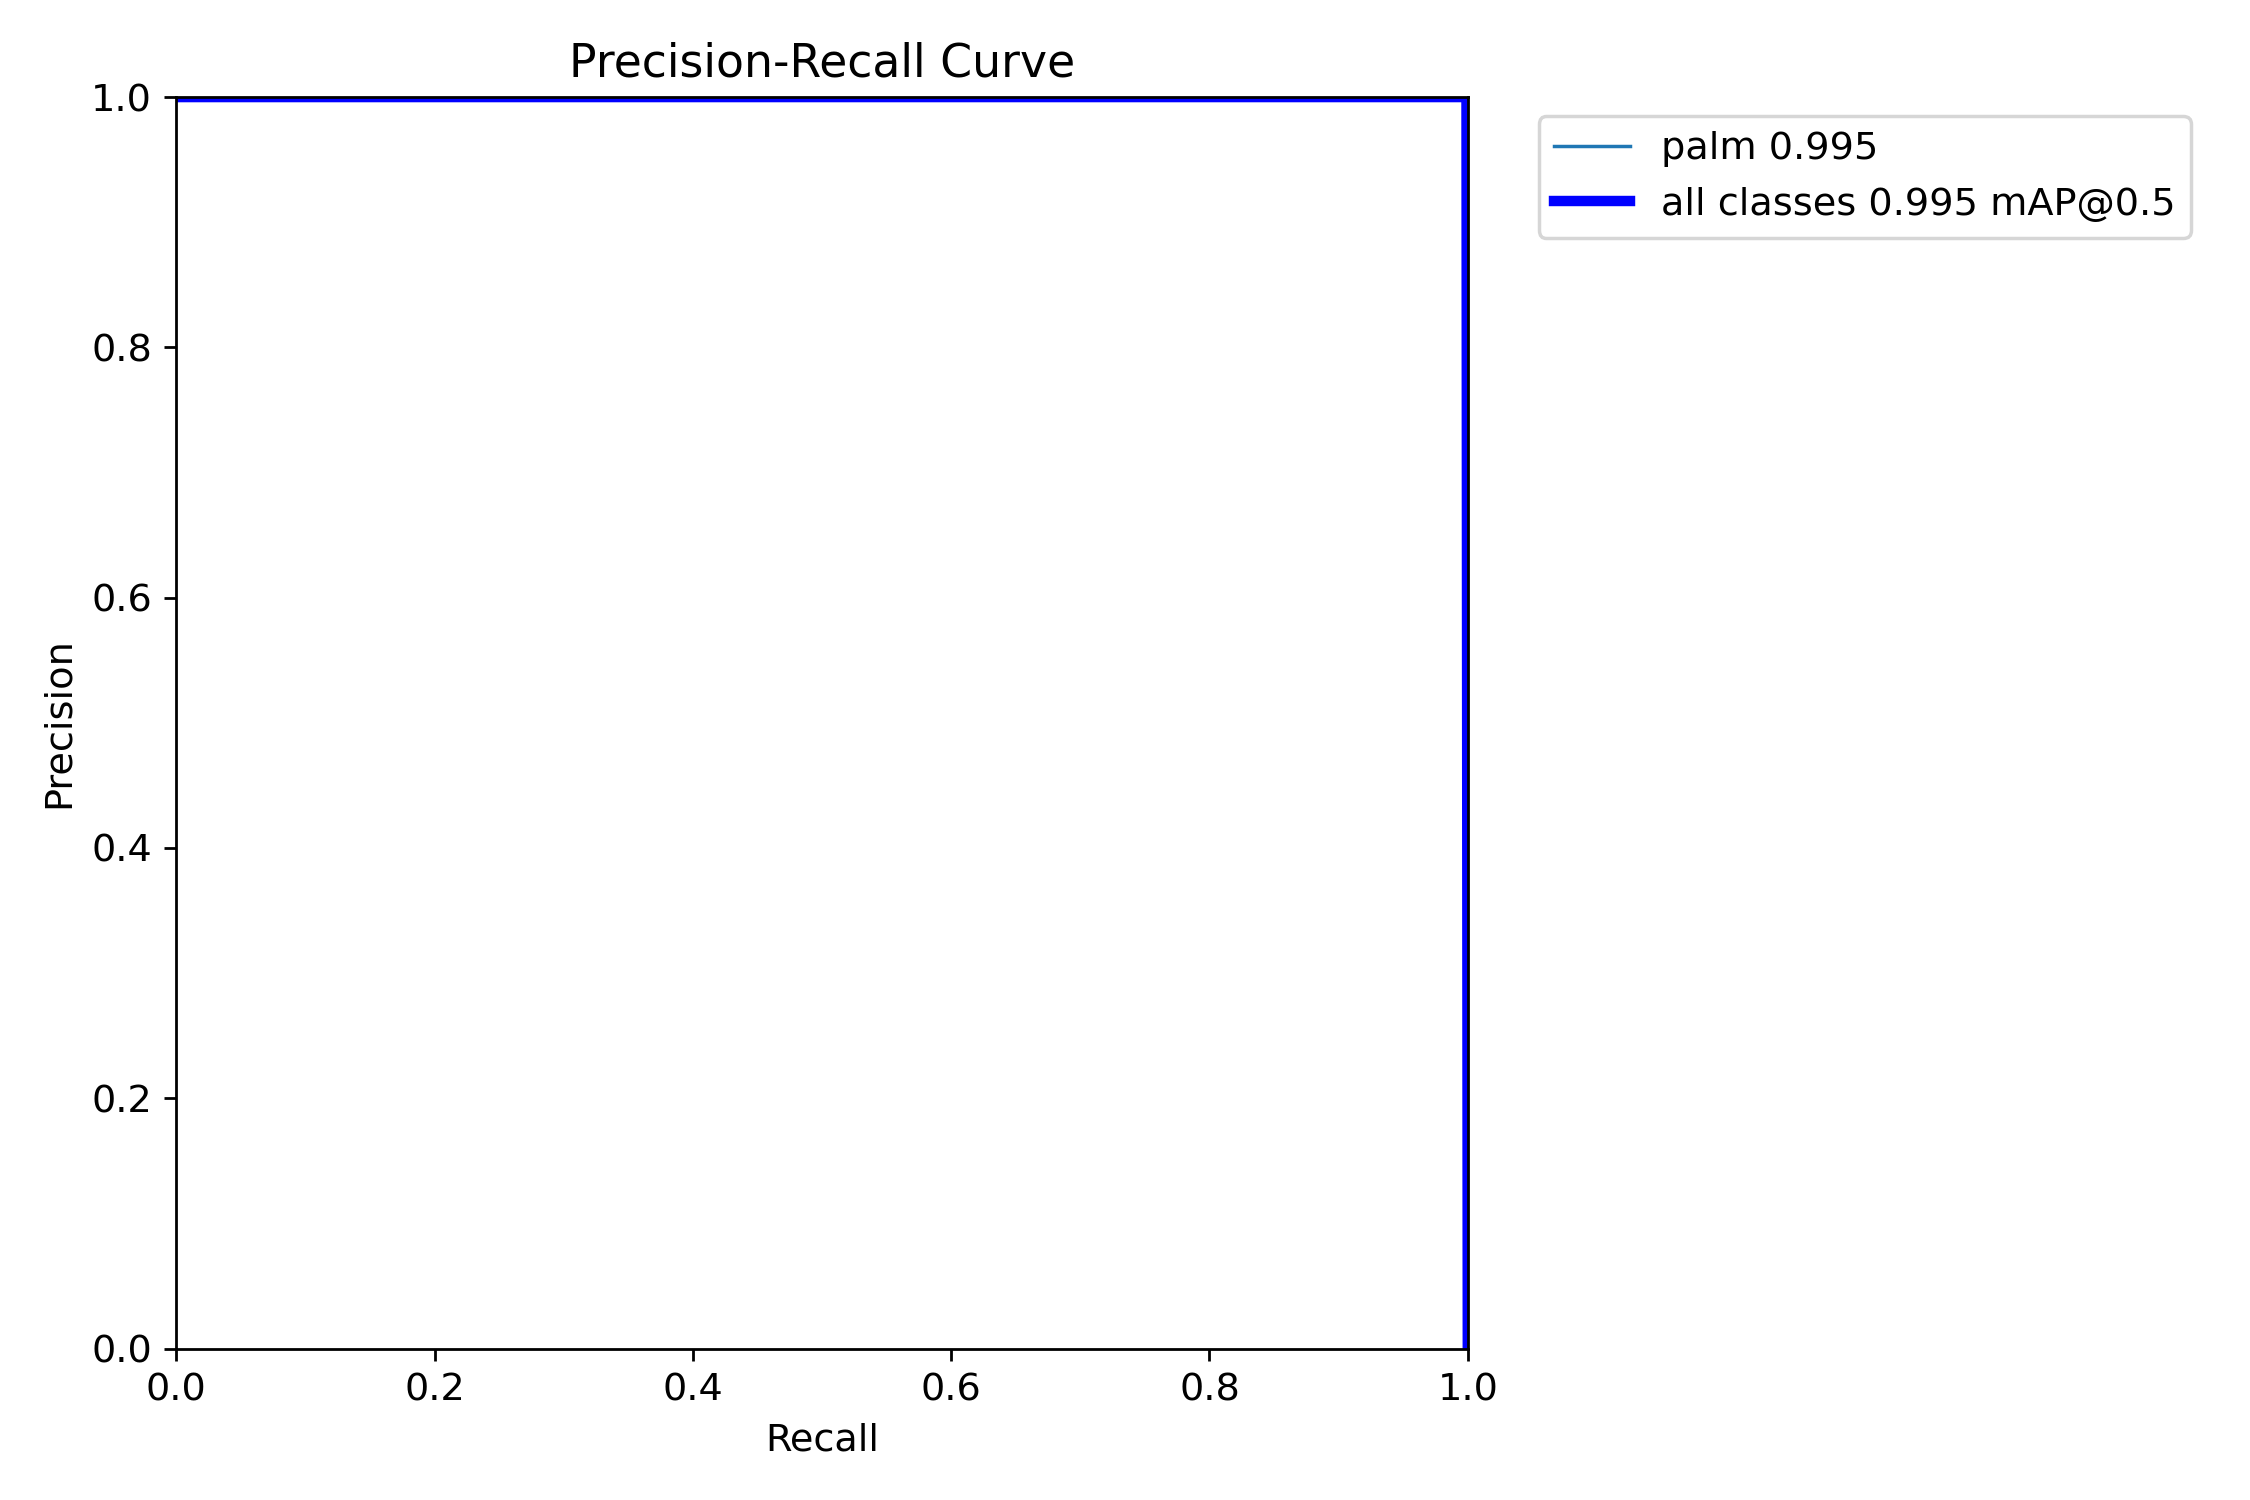

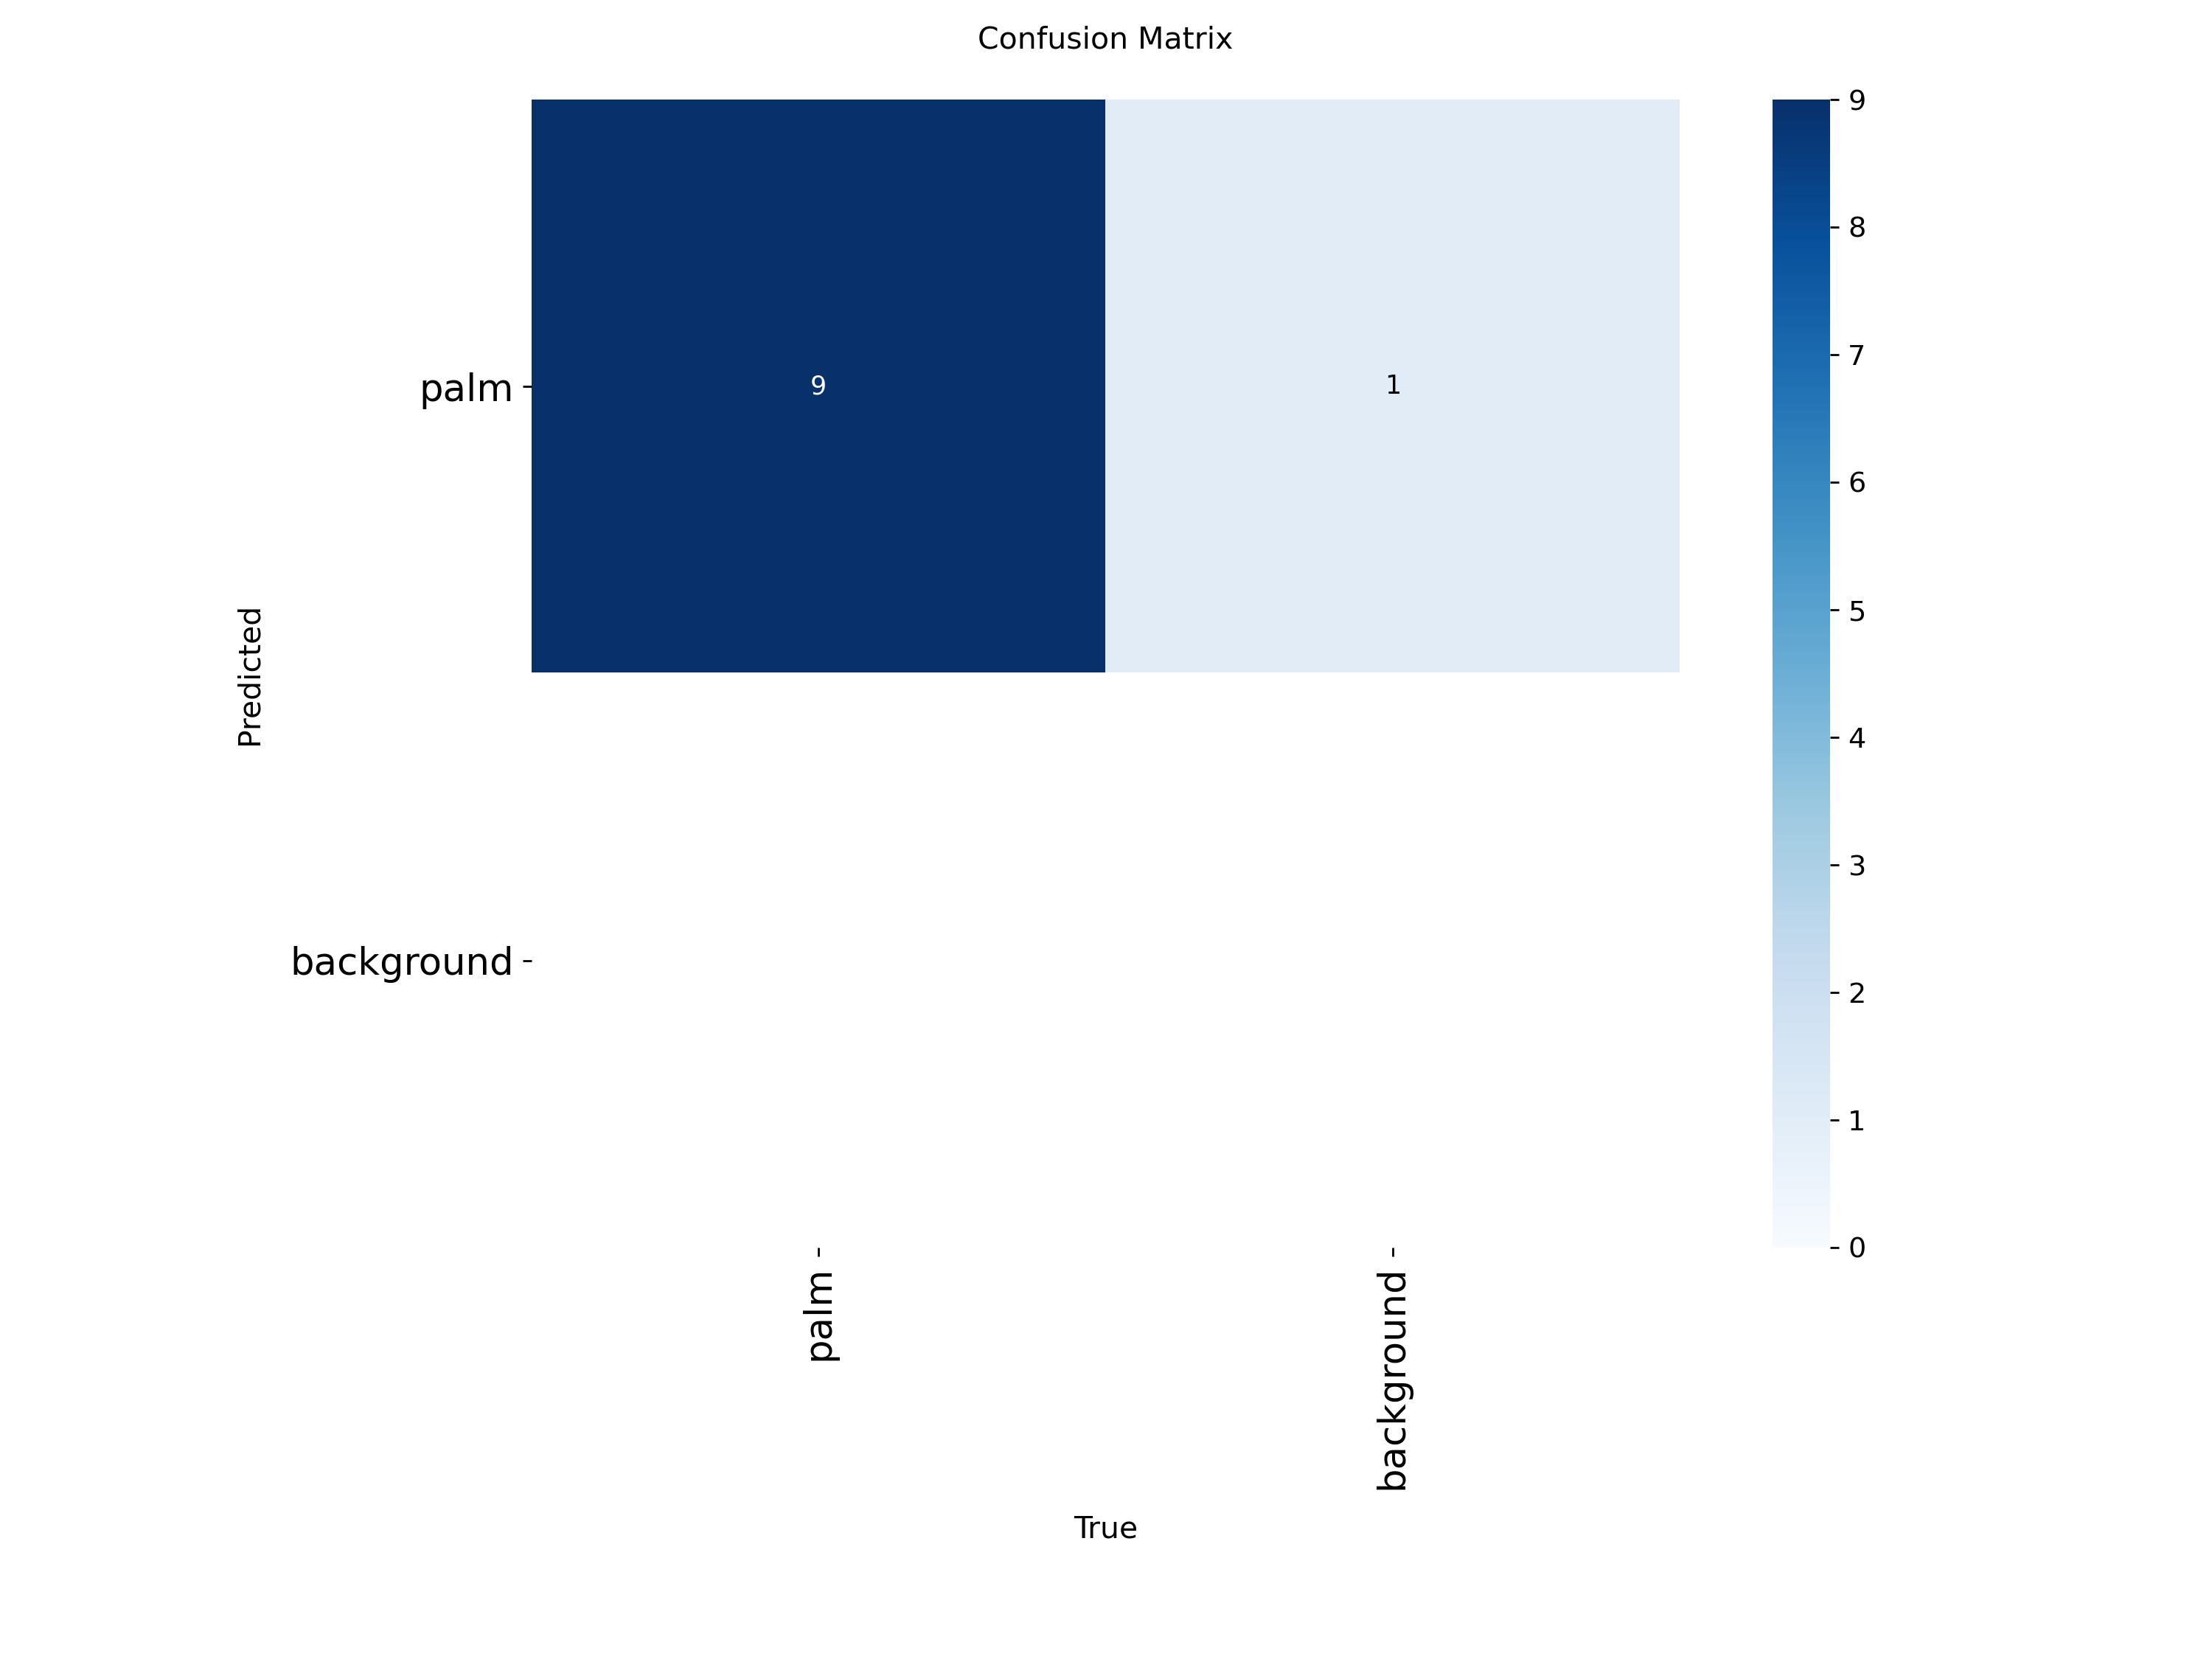

In [8]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train2/results.png'))
display(Image(filename='runs/detect/train2/BoxPR_curve.png'))
display(Image(filename='runs/detect/train2/confusion_matrix.png'))

Model testing

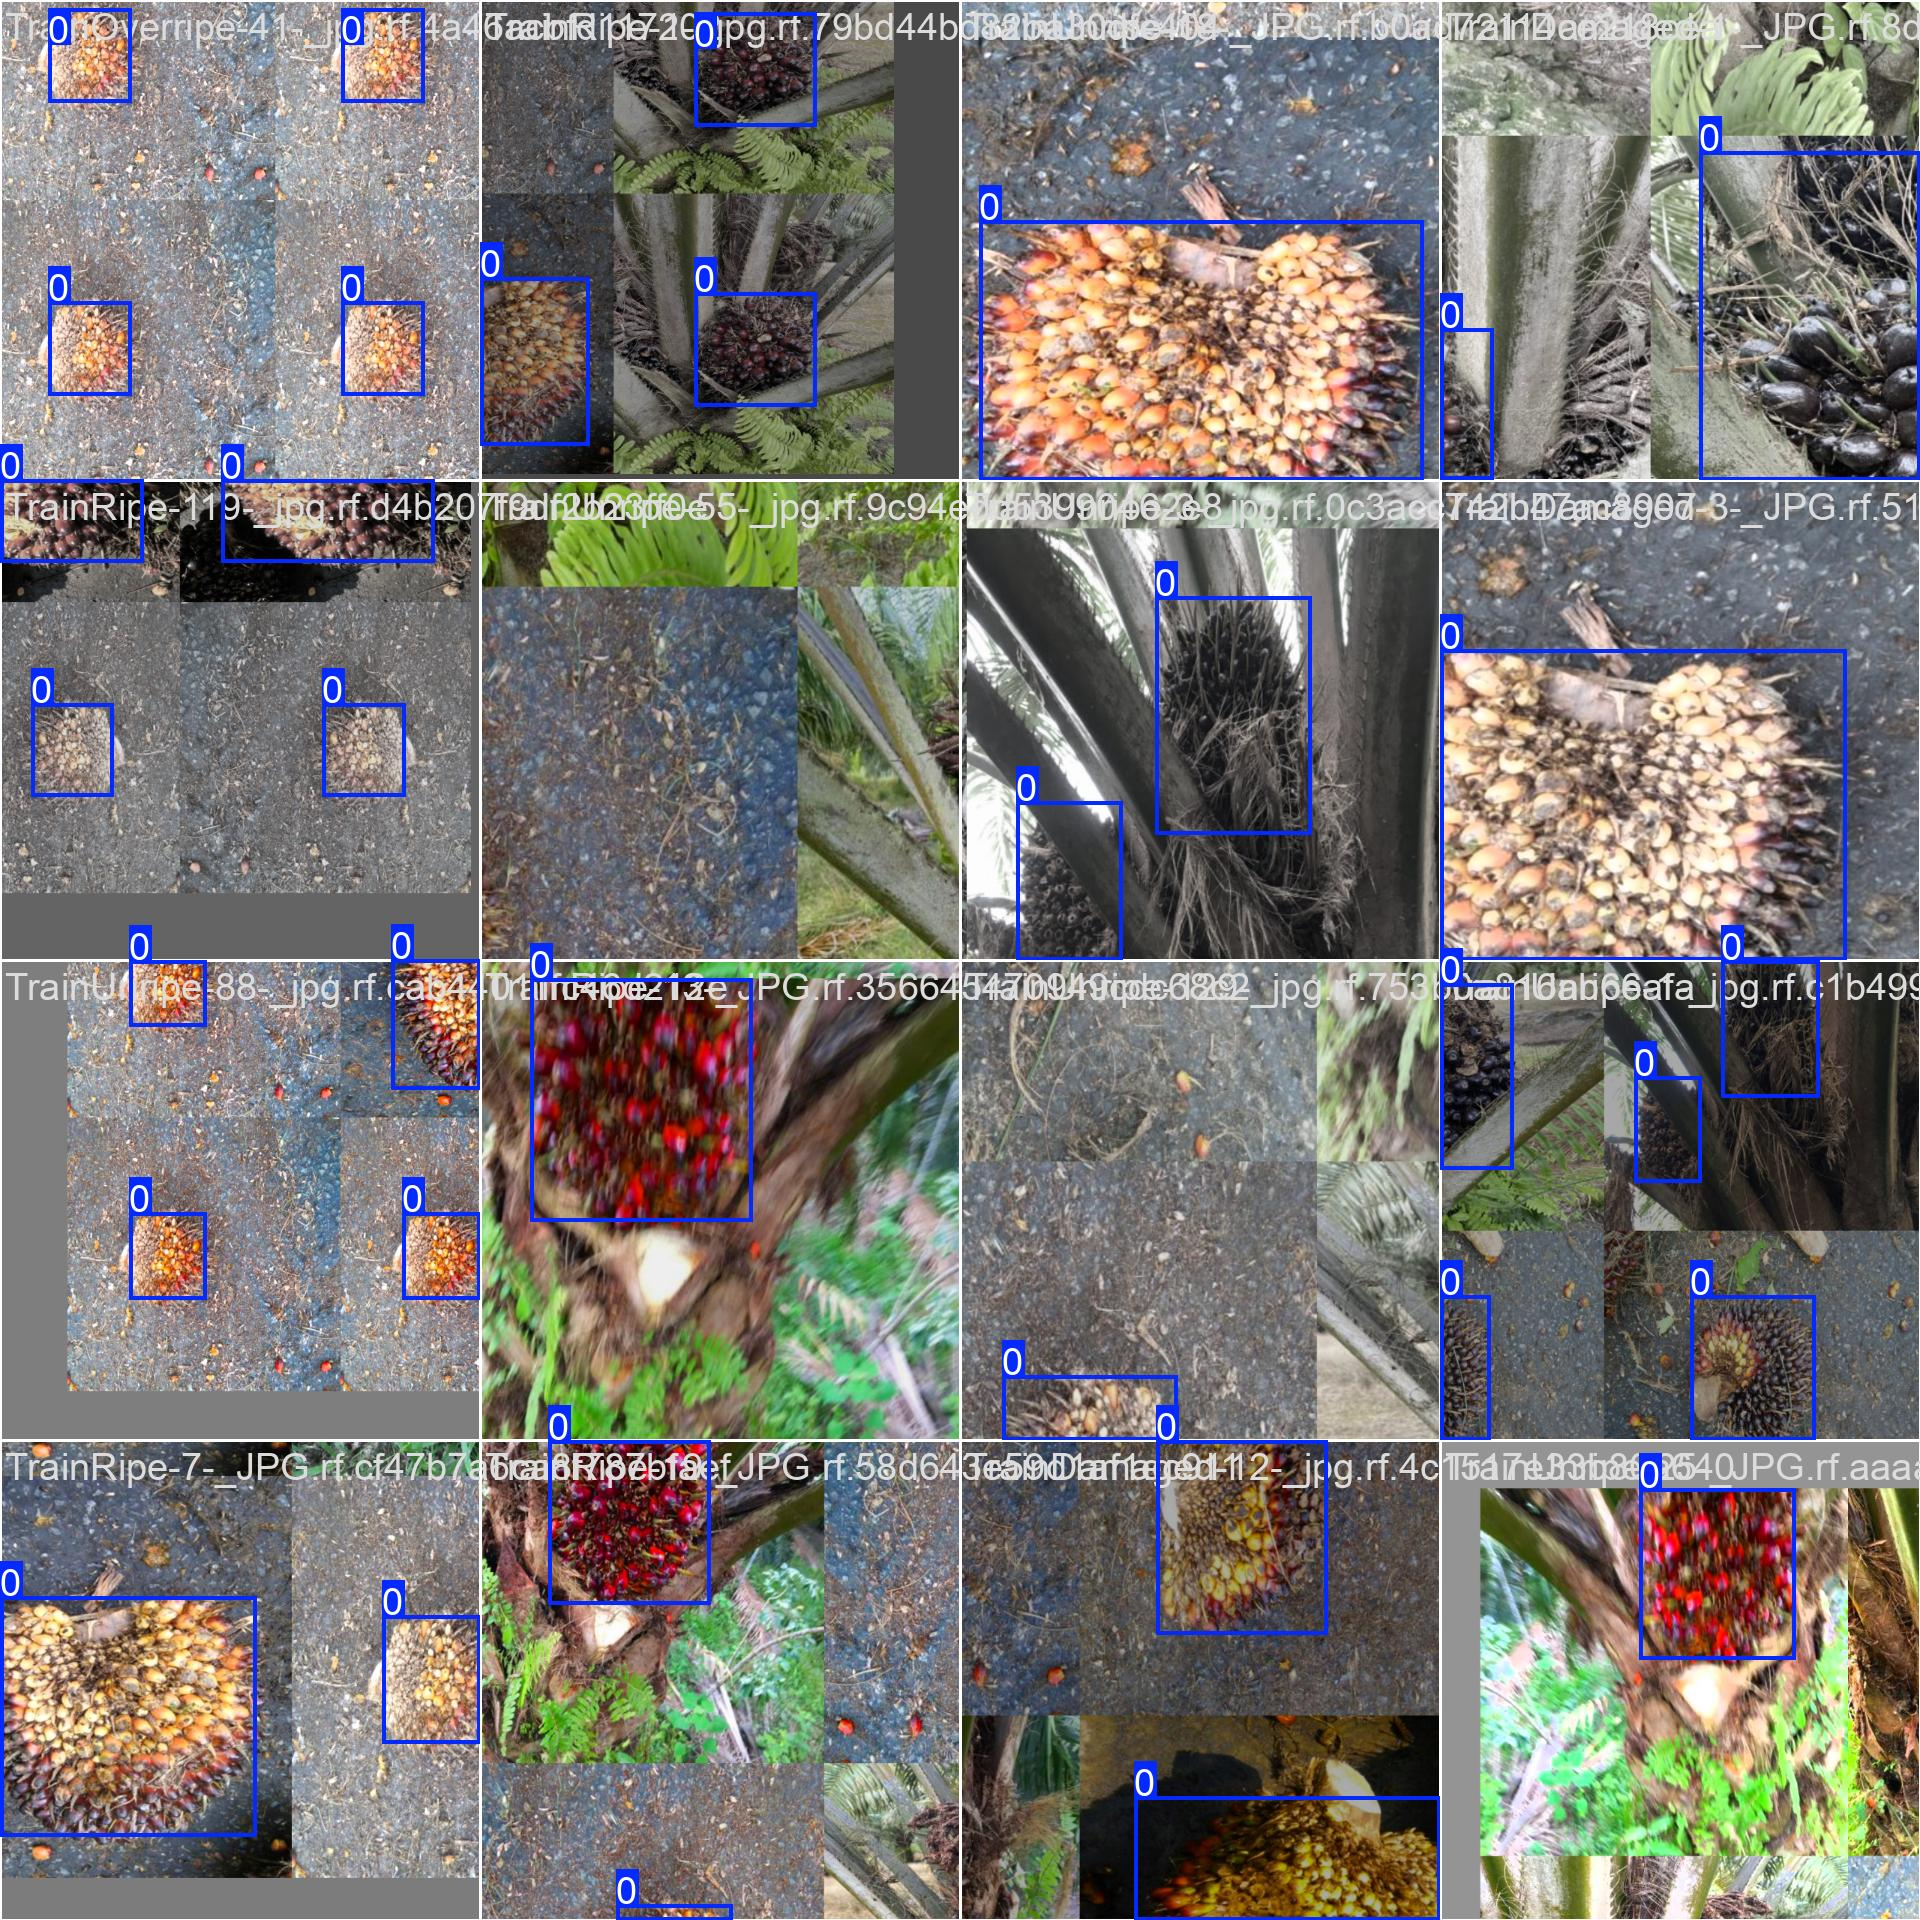

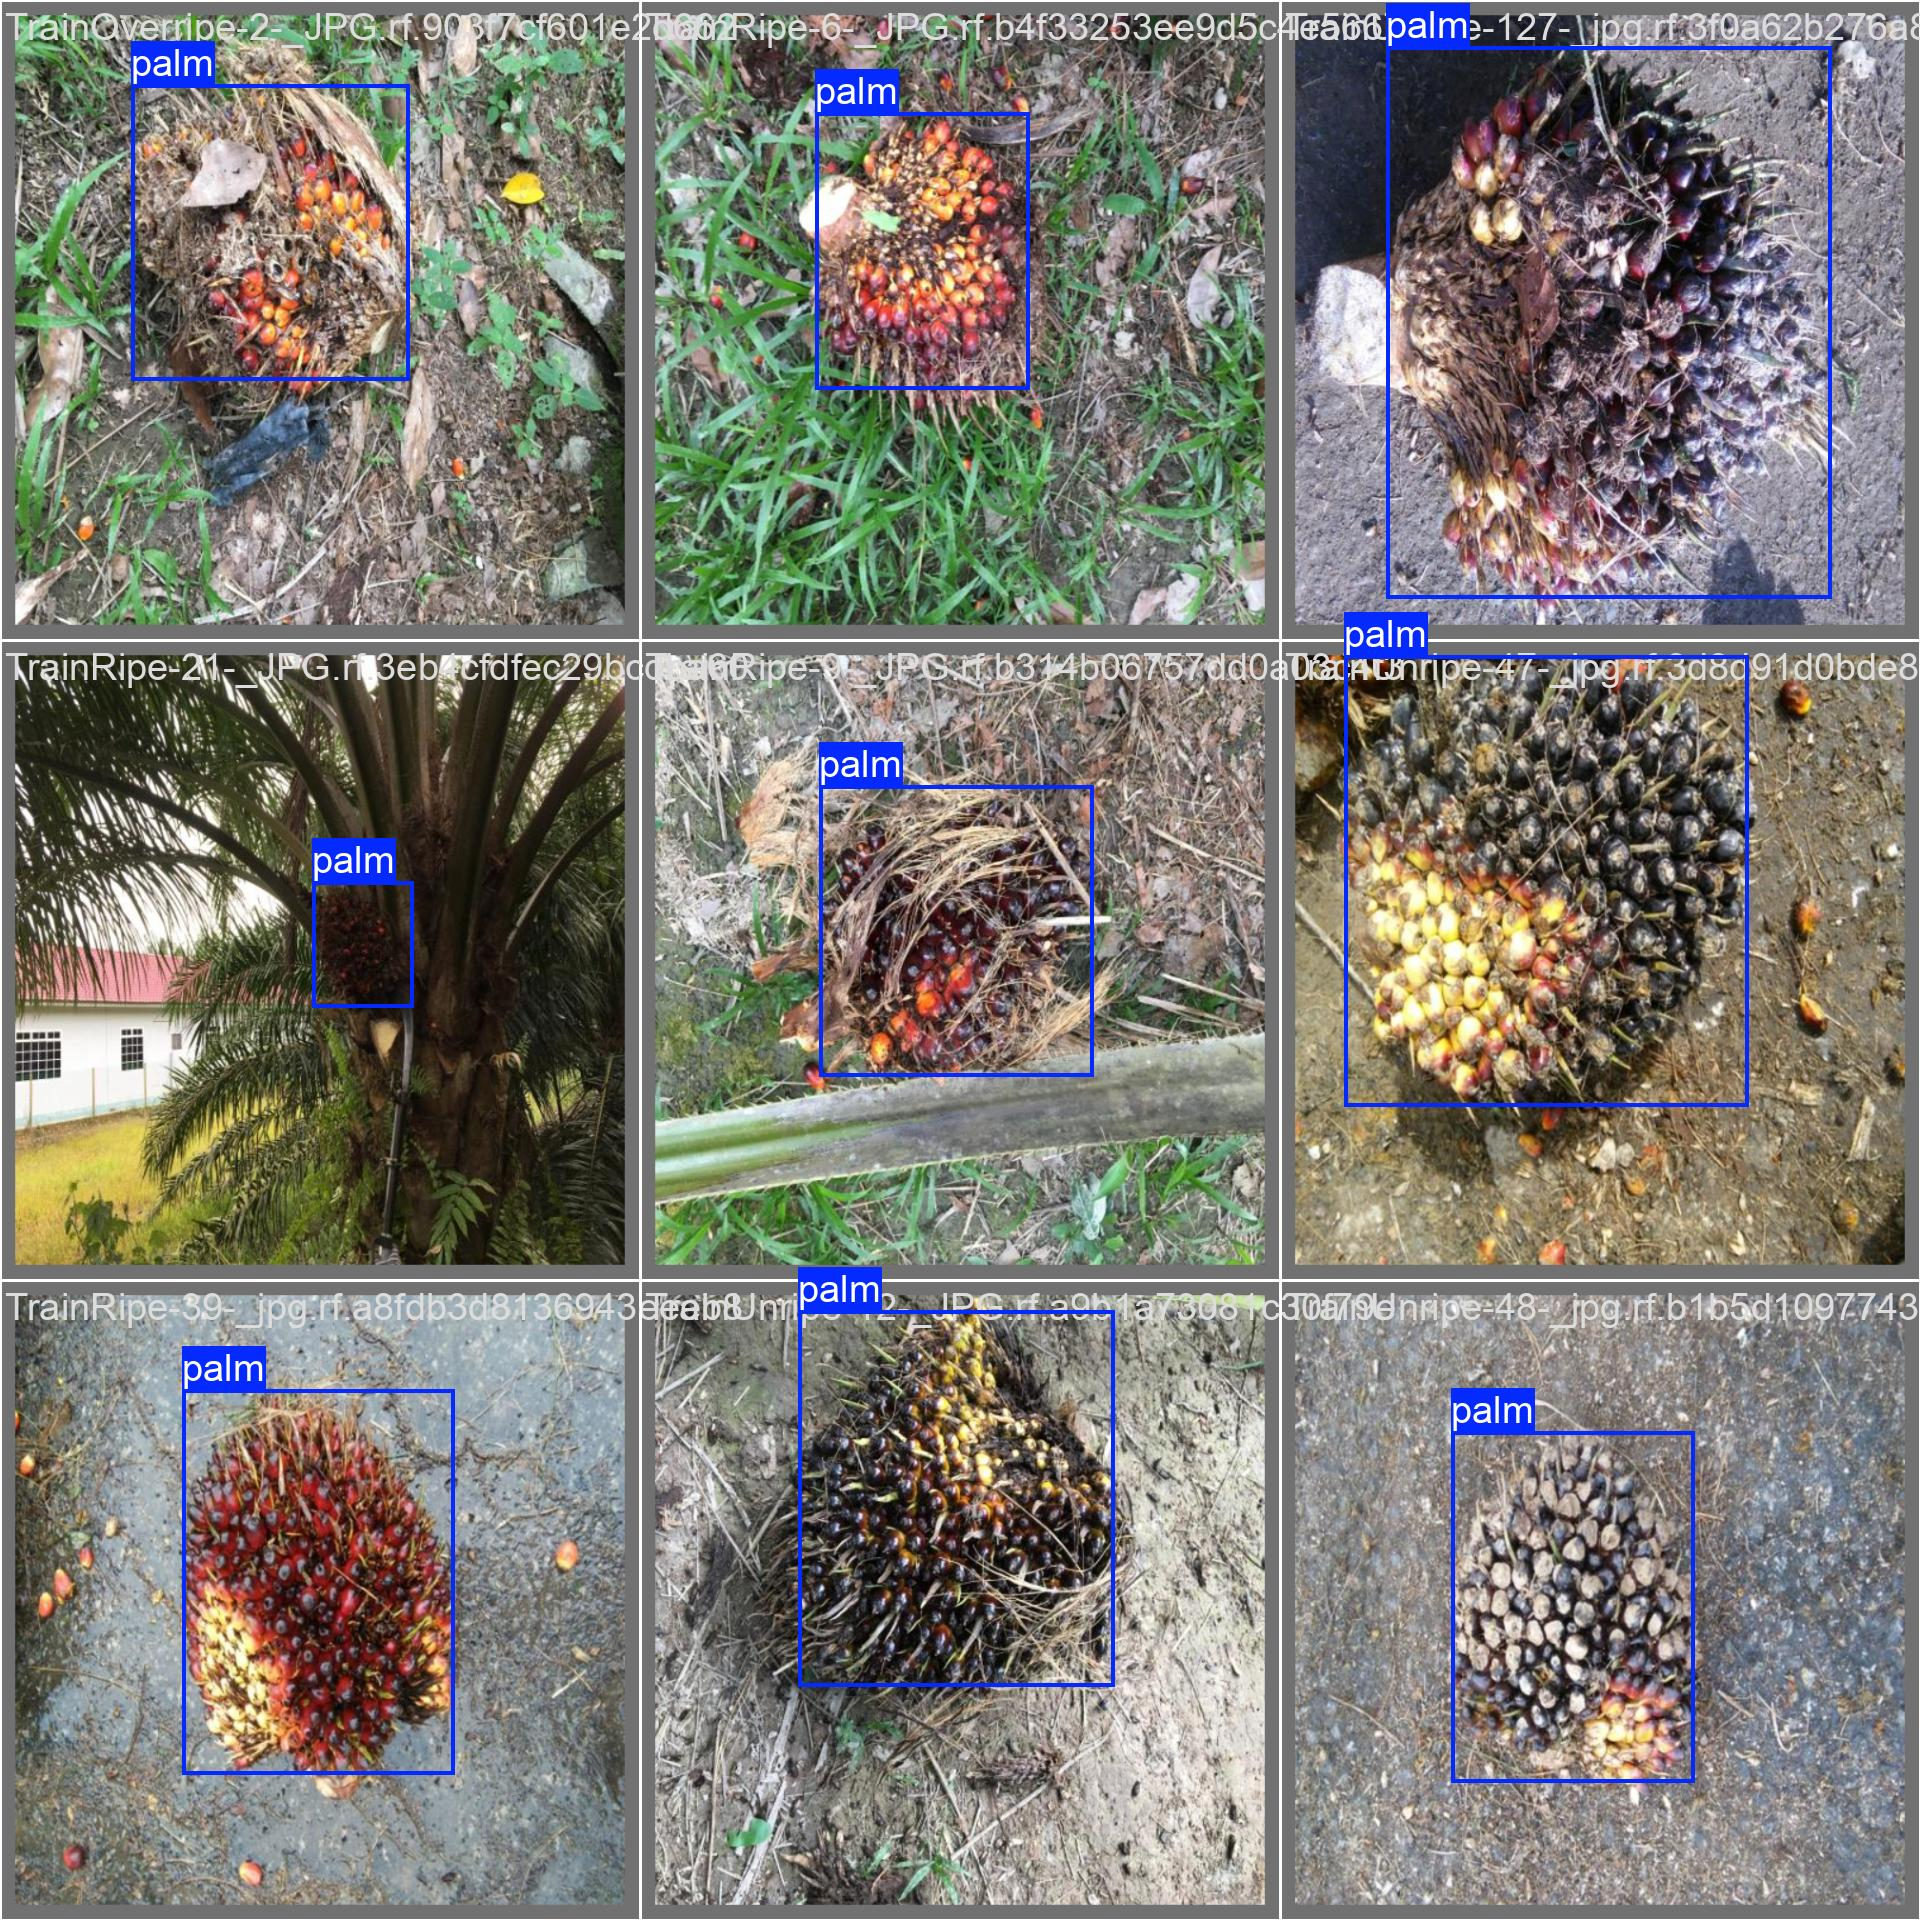

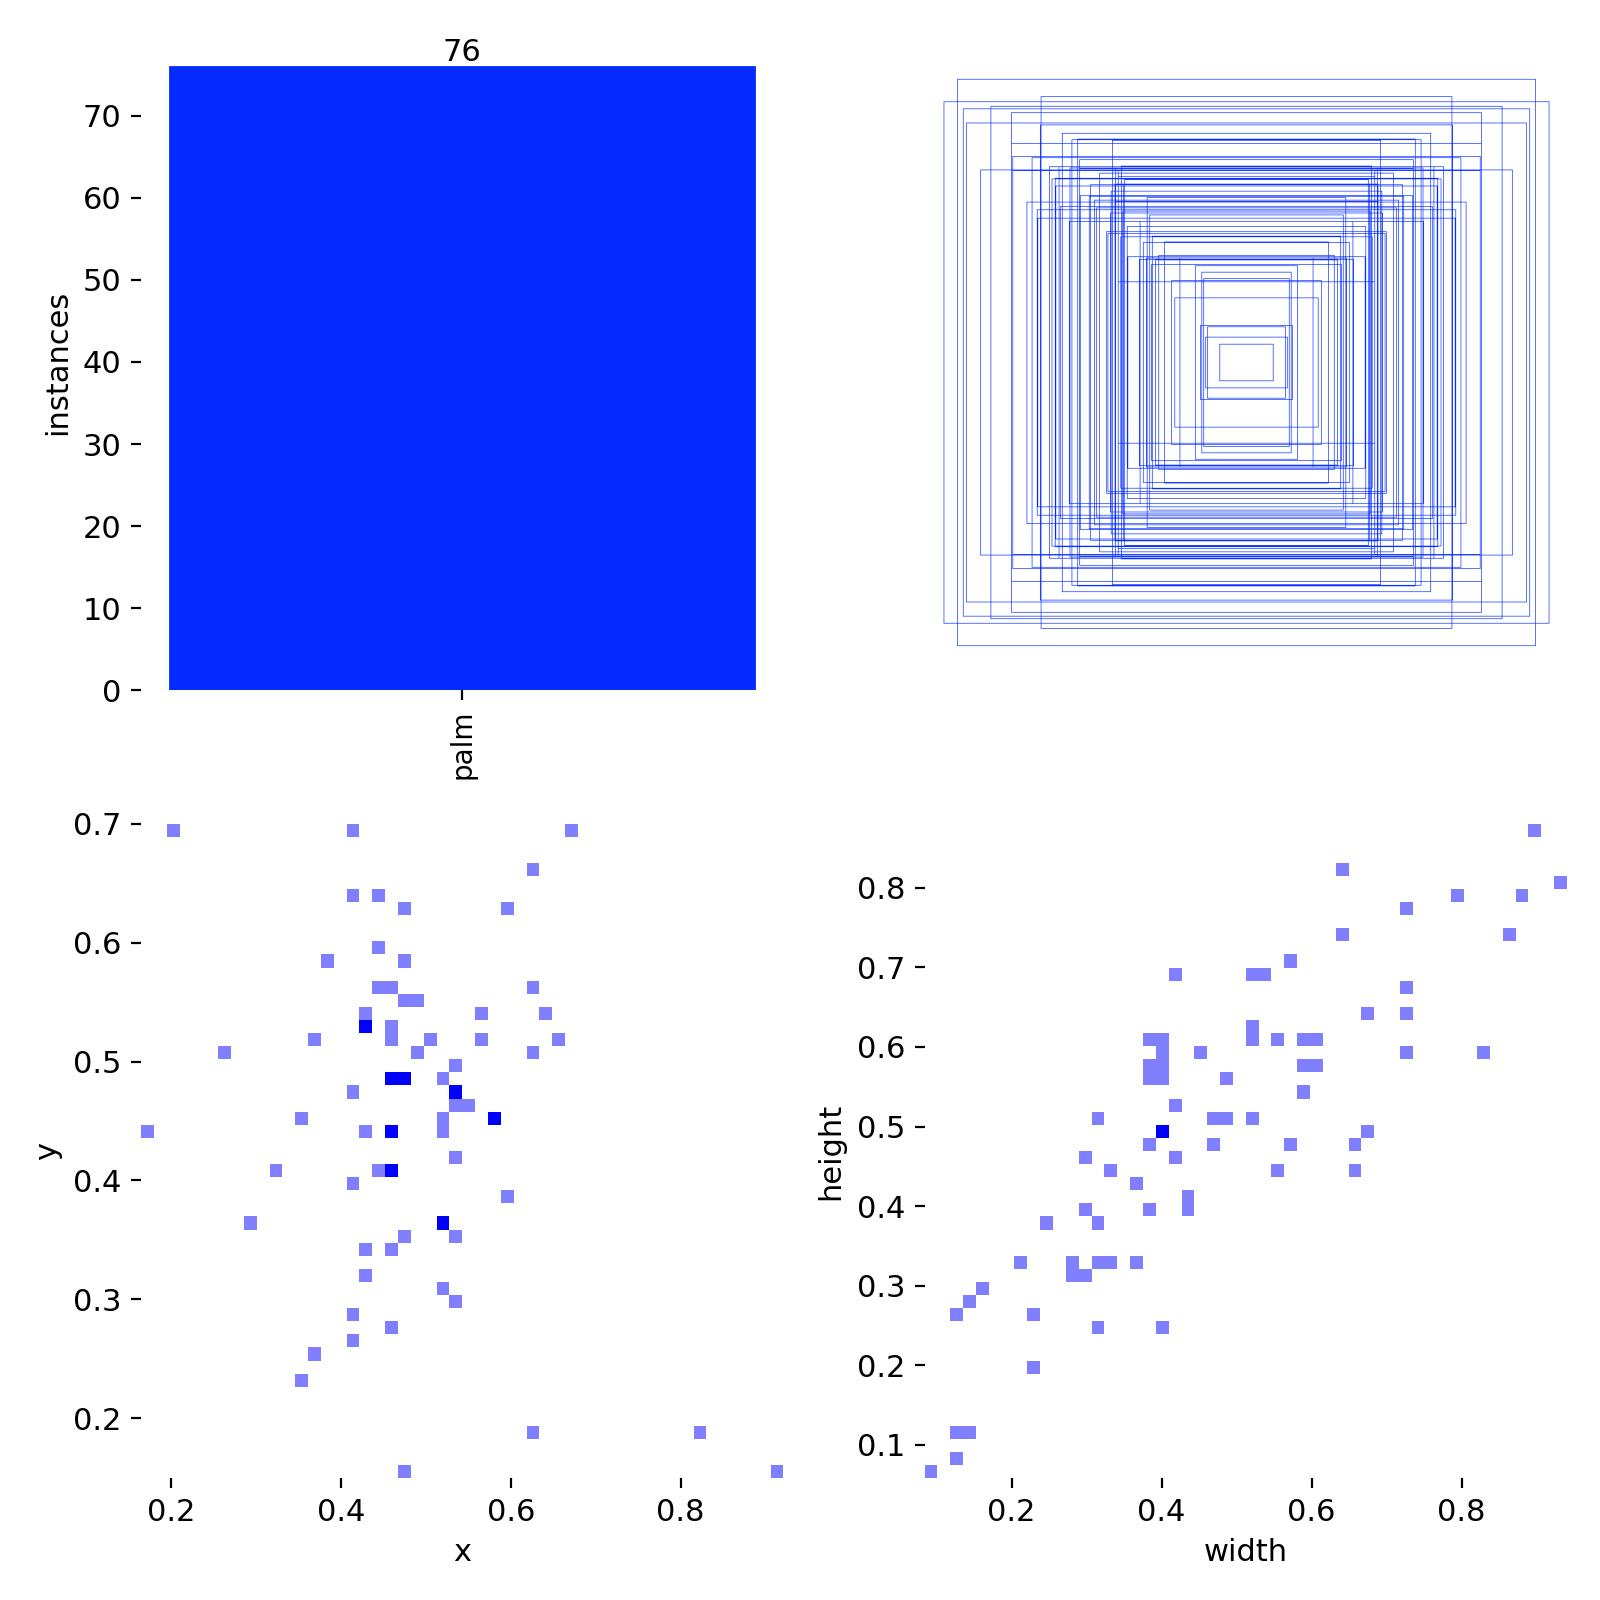

In [9]:
display(Image(filename='runs/detect/train2/train_batch0.jpg'))
display(Image(filename='runs/detect/train2/val_batch0_labels.jpg'))
display(Image(filename='runs/detect/train2/labels.jpg'))

In [11]:
model = YOLO("/content/runs/detect/train2/weights/best.pt")

Model Validation matrics calculation

In [12]:
metrics = model.val(data="/content/palm-tree-1/data.yaml", split="test")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2330.3±558.9 MB/s, size: 84.9 KB)
val: Scanning /content/palm-tree-1/train/labels.cache... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 8.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.4it/s 2.1s
                   all         70         76          1      0.986      0.995      0.818
Speed: 5.7ms preprocess, 10.4ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /content/runs/detect/val


Model Metrics

In [38]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP50: 0.9939736842105265
mAP50-95: 0.8458564417691218
Precision: 0.9868148492828263
Recall: 0.9847979067382887


# **1️⃣ mAP50 (Mean Average Precision at IoU 0.5)**

Definition: Measures how well the model predicts bounding boxes with at least 50% overlap with the ground truth.

Range: 0 → 1 (1 = perfect)

Result: 0.994 → perfect

Model detects nearly all palm trees correctly at IoU ≥ 0.5.

✅ Interpretation: Excellent detection performance at the standard threshold.



# **2️⃣ mAP50-95 (Mean Average Precision across IoU 0.5 to 0.95)**

Definition: Stricter metric, averages AP over multiple IoU thresholds (0.5 → 0.95 in steps of 0.05).

Range: 0 → 1

Result: 0.846 → very good


Model maintains high accuracy even when bounding box overlap must be very precise.


#**3️⃣ Precision**

Precssion =
𝑇
𝑃/
(𝑇
𝑃
+
𝐹
𝑃)
	​


Measures how many detected objects are actually correct

Result: 0.987 → almost perfect

Very few false positives (boxes wrongly detecting background as palm tree).

✅ Interpretation: can trust the model’s detections; no spurious boxes.


# **4️⃣ Recall**

Recall=
𝑇
𝑃/
(𝑇
𝑃
+
𝐹
𝑁)

Measures how many ground truth objects are detected

Result: 0.985 → excellent

The model misses almost no palm trees.

✅ Interpretation: Very few palm trees are undetected.


#📊 Overall Assessment
| Metric      | Value   | Interpretation                             |
|------------|---------|-------------------------------------------|
| mAP50      | 0.994   | Almost all boxes correct at IoU ≥ 0.5     |
| mAP50-95   | 0.846   | Boxes well-aligned even under strict IoU  |
| Precision  | 0.987   | Almost no false positives                  |
| Recall     | 0.985   | Almost no missed palm trees                |

In [39]:
from IPython.display import display, Markdown

# Metrics
mAP50 = 0.994
mAP5095 = 0.846
precision = 0.987
recall = 0.985

# Calculate F1
f1_score = 2 * (precision * recall) / (precision + recall)

# Create Markdown table
table_md = f"""
| Metric      | Value   | Interpretation                             |
|------------|---------|-------------------------------------------|
| mAP50      | {mAP50:.3f}   | Almost all boxes correct at IoU ≥ 0.5     |
| mAP50-95   | {mAP5095:.3f}   | Boxes well-aligned even under strict IoU  |
| Precision  | {precision:.3f}   | Almost no false positives                  |
| Recall     | {recall:.3f}   | Almost no missed palm trees                |
| F1 Score   | {f1_score:.3f}   | Balanced between Precision and Recall      |
"""

# Display in Colab
display(Markdown(table_md))


| Metric      | Value   | Interpretation                             |
|------------|---------|-------------------------------------------|
| mAP50      | 0.994   | Almost all boxes correct at IoU ≥ 0.5     |
| mAP50-95   | 0.846   | Boxes well-aligned even under strict IoU  |
| Precision  | 0.987   | Almost no false positives                  |
| Recall     | 0.985   | Almost no missed palm trees                |
| F1 Score   | 0.986   | Balanced between Precision and Recall      |


In [10]:
metrics = model.val(data="/content/palm-tree-1/data.yaml", split="test")

NameError: name 'model' is not defined